Analyze and compare text similarity recommendations using TF-IDF, Word2Vec CBOW, and Word2Vec Skip-gram models on the text dataset.

In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from collections import Counter
from wordcloud import WordCloud

In [5]:
df_news = pd.read_csv('news.tsv', delimiter='\t')

print("First 5 rows of the DataFrame:")
print(df_news.head())

First 5 rows of the DataFrame:
   N55528 lifestyle lifestyleroyals  \
0  N19639    health      weightloss   
1  N61837      news       newsworld   
2  N53526    health          voices   
3  N38324    health         medical   
4   N2073    sports    football_nfl   

  The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By  \
0                      50 Worst Habits For Belly Fat                       
1  The Cost of Trump's Aid Freeze in the Trenches...                       
2  I Was An NBA Wife. Here's How It Affected My M...                       
3  How to Get Rid of Skin Tags, According to a De...                       
4  Should NFL be able to fine players for critici...                       

  Shop the notebooks, jackets, and more that the royals can't live without.  \
0  These seemingly harmless habits are holding yo...                          
1  Lt. Ivan Molchanets peeked over a parapet of s...                          
2  I felt like I was a fraud, and being 

In [6]:
print("\nDataFrame Info:")
df_news.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51281 entries, 0 to 51280
Data columns (total 8 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                                                                                                                                                                            

### Task#1: Text Preprocessing

Apply a series of preprocessing steps to clean the text data. This includes removing URLs and special characters, converting text to lowercase, removing stopwords, performing stemming or lemmatization, and tokenizing the text. These steps are crucial for preparing the text for vectorization.


In [7]:
# Rename columns based on the head() output and instructions
df_news.rename(columns={df_news.columns[3]: 'title', df_news.columns[4]: 'article_text'}, inplace=True)
df_news['article_text'] = df_news['article_text'].fillna('')

stop_words = set(stopwords.words('english'))    # Initialize NLTK components
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):    # Preprocessing function
    text = str(text).lower()                                                
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) 
    text = re.sub(r'[^a-zA-Z]', ' ', text)                                  
    tokens = word_tokenize(text)

    # Remove stopwords and apply lemmatization
    processed_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(processed_tokens)   # Join the processed words back into a single string

df_news['processed_text'] = df_news['article_text'].apply(preprocess_text)
print("First 5 rows with original and processed text:")
print(df_news[['article_text', 'processed_text']].head())

First 5 rows with original and processed text:
                                        article_text  \
0  These seemingly harmless habits are holding yo...   
1  Lt. Ivan Molchanets peeked over a parapet of s...   
2  I felt like I was a fraud, and being an NBA wi...   
3  They seem harmless, but there's a very good re...   
4  Several fines came down against NFL players fo...   

                                      processed_text  
0  seemingly harmless habit holding back keeping ...  
1  lt ivan molchanets peeked parapet sand bag fro...  
2  felt like fraud nba wife help fact nearly dest...  
3  seem harmless good reason ignore post get rid ...  
4  several fine came nfl player criticizing offic...  


### Data Exploration and Visualization

Explore the preprocessed text data by visualizing the most frequent unigrams, bigrams, and trigrams using bar plots.


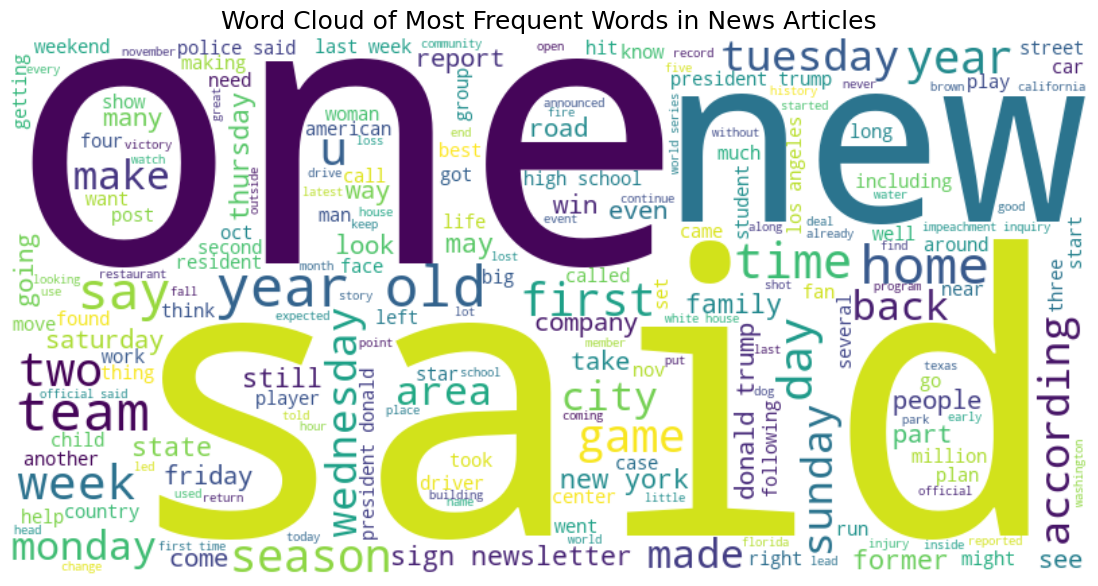

In [8]:
all_words = ' '.join(df_news['processed_text'])  # Combine all processed text into a single string
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=200).generate(all_words)  # Generate a word cloud

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Words in News Articles', fontsize=18)
plt.show()

In [9]:
# Function to get n-grams from a list of words
def get_ngrams(words, n):
    return list(ngrams(words, n))

# Extract unigrams, bigrams, and trigrams

unigrams_list = []
for text in df_news['processed_text']:
    unigrams_list.extend(text.split())

bigrams_list = []
trigrams_list = []
for text in df_news['processed_text']:
    words = text.split()
    bigrams_list.extend(get_ngrams(words, 2))
    trigrams_list.extend(get_ngrams(words, 3))

In [10]:
# Count the frequency of the top 20 unigrams \ bigrams \ trigrams

unigram_counts = Counter(unigrams_list)
top_20_unigrams = unigram_counts.most_common(20)

bigram_counts = Counter(bigrams_list)
top_20_bigrams = bigram_counts.most_common(20)

trigram_counts = Counter(trigrams_list)
top_20_trigrams = trigram_counts.most_common(20)

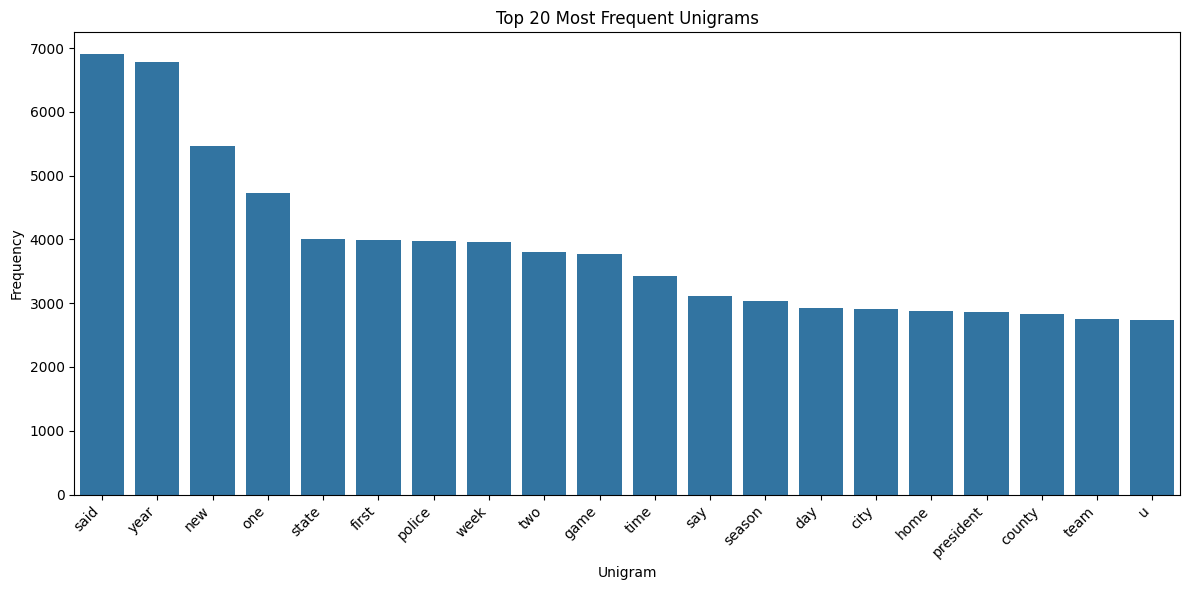

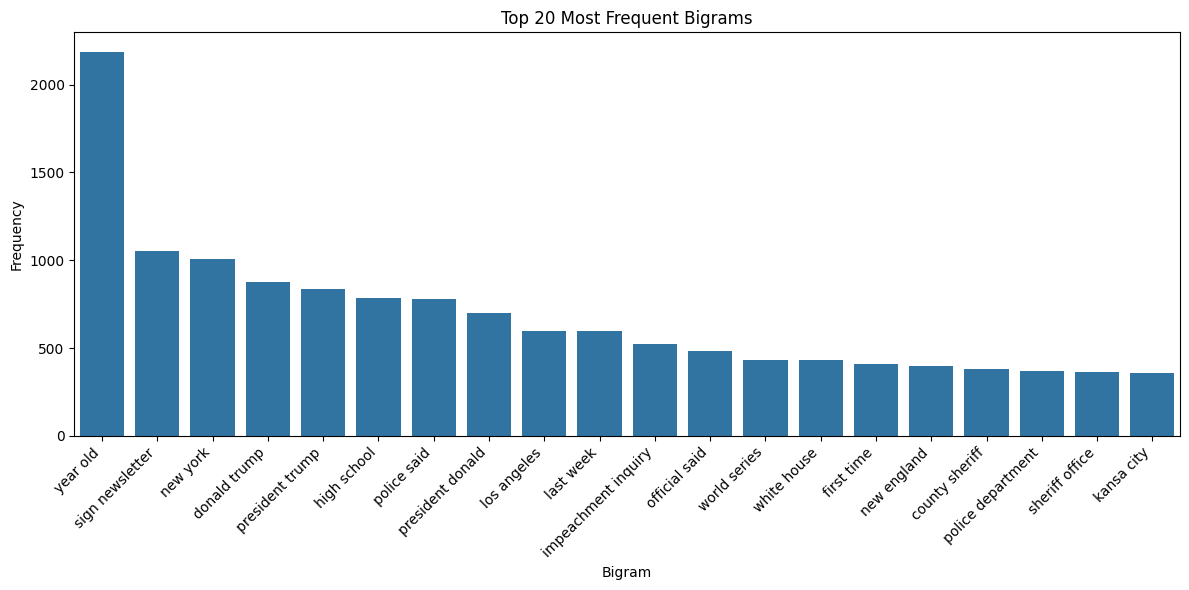

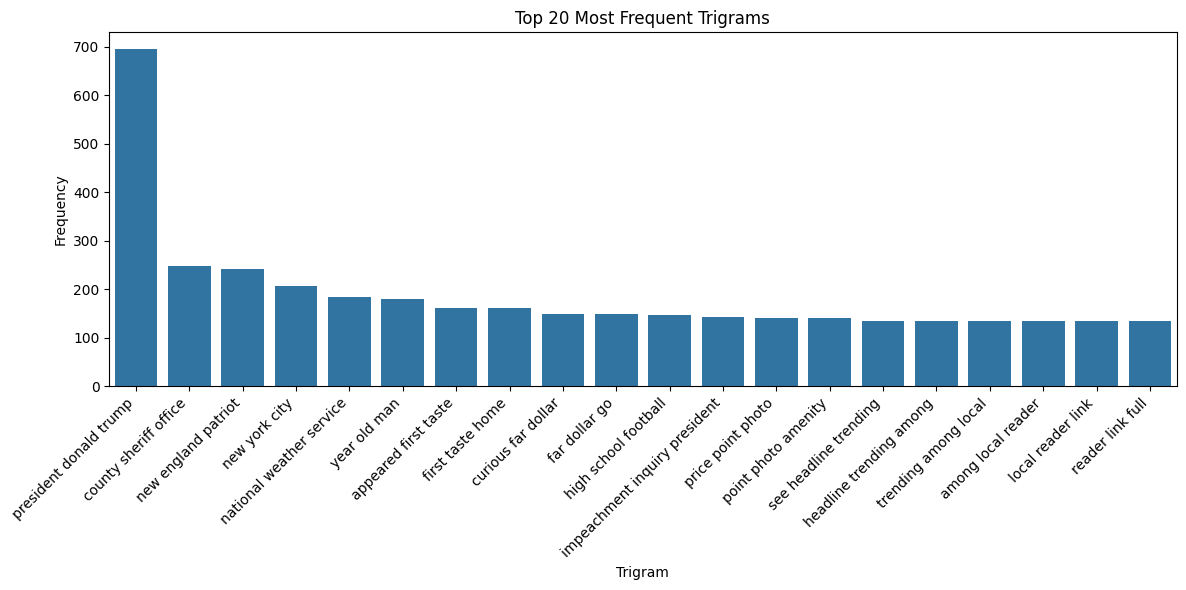

In [11]:
# Plotting function for n-grams
def plot_ngrams(ngram_data, title, x_label, y_label):
    # Convert n-gram tuples to strings for plotting
    processed_ngram_data = []
    for ngram, count in ngram_data:
        if isinstance(ngram, tuple):
            processed_ngram_data.append((' '.join(ngram), count))
        else:
            processed_ngram_data.append((ngram, count))

    df_ngram = pd.DataFrame(processed_ngram_data, columns=[x_label, y_label])
    plt.figure(figsize=(12, 6))
    sns.barplot(x=x_label, y=y_label, data=df_ngram)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


plot_ngrams(top_20_unigrams, 'Top 20 Most Frequent Unigrams', 'Unigram', 'Frequency')  # Plot Top 20 Unigrams
plot_ngrams(top_20_bigrams, 'Top 20 Most Frequent Bigrams', 'Bigram', 'Frequency')     # Plot Top 20 Bigrams
plot_ngrams(top_20_trigrams, 'Top 20 Most Frequent Trigrams', 'Trigram', 'Frequency')  # Plot Top 20 Trigrams


### Task#2: Generate TF-IDF Matrix

Create a TF-IDF (Term Frequency-Inverse Document Frequency) matrix from the preprocessed text data. This matrix will represent the documents as sparse vectors.


In [12]:
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the 'processed_text' column to create the TF-IDF matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(df_news['processed_text'])
print("Shape of TF-IDF matrix:", tfidf_matrix.shape)

Shape of TF-IDF matrix: (51281, 43610)


### TF-IDF Cosine Similarity Function

Develop a function to compute cosine similarity between a user query (input text) and all documents in the dataset using their TF-IDF vectors. This function will be used to find similar texts.


In [13]:
def calculate_tfidf_cosine_similarity(query):
    processed_query = preprocess_text(query)                     # Preprocess the query using the previously defined function
    query_tfidf = tfidf_vectorizer.transform([processed_query])  # Transform the preprocessed query into a TF-IDF vector

    cosine_similarities = cosine_similarity(query_tfidf, tfidf_matrix)
    return cosine_similarities.flatten()


### TF-IDF Recommendations

Use the TF-IDF cosine similarity function to recommend the top 5 most similar texts from the dataset based on a given user query.


In [14]:
user_query = "latest news about technology" # Define a sample user query string
cosine_similarities = calculate_tfidf_cosine_similarity(user_query)

# Get the indices of the top 5 most similar documents
# Use argsort to get indices that would sort the array, then take the last 5 (highest values)
# and reverse them to get in descending order of similarity.
top_5_indices = np.argsort(cosine_similarities)[-5:][::-1]

print(f"Top 5 recommendations for query: '{user_query}'\n")
for i, idx in enumerate(top_5_indices):
    print(f"Recommendation {i+1}:")
    print(f"Title: {df_news.loc[idx, 'title']}")
    print(f"Article Text: {df_news.loc[idx, 'article_text']}\n")

Top 5 recommendations for query: 'latest news about technology'

Recommendation 1:
Title: Cowboys News: Just how much of an impact will Michael Bennett have?
Article Text: Check out the latest news about your Dallas Cowboys.

Recommendation 2:
Title: Road closures, wall design, and other Gordie Howe Bridge updates
Article Text: All the latest news about the 1.5-mile international crossing

Recommendation 3:
Title: Black and Gold Links: Ola Adeniyi could see his first NFL start vs. the Dolphins in Week 8
Article Text: Time to check on the latest news surrounding the Pittsburgh Steelers.

Recommendation 4:
Title: Black and Gold Links: The Dolphins are leaving players behind heading into the NFL trade deadline
Article Text: Time to check on the latest news surrounding the Pittsburgh Steelers.

Recommendation 5:
Title: Black and Gold Links: Vince Williams, of all people, picking up the slack for Stephon Tuitt
Article Text: Time to check on the latest news surrounding the Pittsburgh Steeler

### Task#3: Train Word2Vec Models

Train two Word2Vec models on the preprocessed text data: one using the Continuous Bag-of-Words (CBOW) architecture and another using the Skip-gram architecture. These models will generate dense word embeddings.


In [15]:
# Prepare the data for Word2Vec -> list of tokenized sentences
sentences = [text.split() for text in df_news['processed_text']]

print("Training Word2Vec CBOW model...")
cbow_model = Word2Vec(
    sentences,
    vector_size=100, # Dimensionality of the word vectors
    window=5,        # Maximum distance between the current and predicted word within a sentence
    min_count=1,     # Ignores all words with total frequency lower than this
    workers=4,       # Use these many worker threads to train the model
    sg=0             # 0 for CBOW
)
print("Word2Vec CBOW model trained successfully.")

print("Training Word2Vec Skip-gram model...")
skipgram_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1           # 1 for Skip-gram
)
print("Word2Vec Skip-gram model trained successfully.")

Training Word2Vec CBOW model...
Word2Vec CBOW model trained successfully.
Training Word2Vec Skip-gram model...
Word2Vec Skip-gram model trained successfully.


### Generate Average Word Embeddings

Convert each document and the user query into average word embeddings using the trained Word2Vec models (both CBOW and Skip-gram). This will provide dense vector representations for documents and queries.


In [16]:
def get_document_embedding(model, document_words):
    # Filter out words that are not in the model's vocabulary
    meaningful_words = [word for word in document_words if word in model.wv]

    if not meaningful_words:
        # Return a zero vector if no words from the document are in the vocabulary
        return np.zeros(model.vector_size)
    else:
        # Get vectors for meaningful words and calculate their mean
        return np.mean([model.wv[word] for word in meaningful_words], axis=0)

# Apply the function to get CBOW document embeddings
cbow_document_embeddings = [
    get_document_embedding(cbow_model, text.split())
    for text in df_news['processed_text']
]

# Apply the function to get Skip-gram document embeddings
skipgram_document_embeddings = [
    get_document_embedding(skipgram_model, text.split())
    for text in df_news['processed_text']
]

# Preprocess the user_query
processed_user_query = preprocess_text(user_query)
query_tokens = processed_user_query.split()

cbow_query_embedding = get_document_embedding(cbow_model, query_tokens)            # Generate CBOW embedding for the user query
skipgram_query_embedding = get_document_embedding(skipgram_model, query_tokens)    # Generate Skip-gram embedding for the user query

cbow_document_embeddings_array = np.array(cbow_document_embeddings)                # Convert lists to NumPy arrays for shape checking
skipgram_document_embeddings_array = np.array(skipgram_document_embeddings)

# Print the shapes of the document embeddings
print("Shape of CBOW document embeddings:", cbow_document_embeddings_array.shape)
print("Shape of Skip-gram document embeddings:", skipgram_document_embeddings_array.shape)
print("Shape of CBOW query embedding:", cbow_query_embedding.shape)
print("Shape of Skip-gram query embedding:", skipgram_query_embedding.shape)

Shape of CBOW document embeddings: (51281, 100)
Shape of Skip-gram document embeddings: (51281, 100)
Shape of CBOW query embedding: (100,)
Shape of Skip-gram query embedding: (100,)


### Word2Vec Cosine Similarity

Compute cosine similarity between the user query and all documents using their average word embeddings generated by both CBOW and Skip-gram models.


In [17]:
def calculate_word2vec_cosine_similarity(query_embedding, document_embeddings_array):
    # Reshape the query embedding to (1, -1) as required by cosine_similarity
    query_embedding_reshaped = query_embedding.reshape(1, -1)

    cosine_similarities = cosine_similarity(query_embedding_reshaped, document_embeddings_array)
    return cosine_similarities.flatten()

# Calculate CBOW \ Skip-gram cosine similarities

cbow_cosine_similarities = calculate_word2vec_cosine_similarity(cbow_query_embedding, cbow_document_embeddings_array)
skipgram_cosine_similarities = calculate_word2vec_cosine_similarity(skipgram_query_embedding, skipgram_document_embeddings_array)

print("CBOW cosine similarities calculated. Shape:", cbow_cosine_similarities.shape)
print("Skip-gram cosine similarities calculated. Shape:", skipgram_cosine_similarities.shape)

CBOW cosine similarities calculated. Shape: (51281,)
Skip-gram cosine similarities calculated. Shape: (51281,)


### Word2Vec Recommendations

Recommend the top 5 most similar texts based on cosine similarity computed with both CBOW and Skip-gram word embeddings. This step will also involve comparing the recommendations from both Word2Vec approaches.


In [18]:
# Get the indices of the top 5 most similar documents for CBOW & Skip-gram and finally show the recommendations

cbow_top_5_indices = np.argsort(cbow_cosine_similarities)[-5:][::-1]   
print(f"\nTop 5 CBOW recommendations for query: '{user_query}'\n")     
for i, idx in enumerate(cbow_top_5_indices):
    print(f"Recommendation {i+1} (CBOW):")
    print(f"Title: {df_news.loc[idx, 'title']}")
    print(f"Article Text: {df_news.loc[idx, 'article_text']}\n")

skipgram_top_5_indices = np.argsort(skipgram_cosine_similarities)[-5:][::-1]
print(f"\nTop 5 Skip-gram recommendations for query: '{user_query}'\n")
for i, idx in enumerate(skipgram_top_5_indices):
    print(f"Recommendation {i+1} (Skip-gram):")
    print(f"Title: {df_news.loc[idx, 'title']}")
    print(f"Article Text: {df_news.loc[idx, 'article_text']}\n")


Top 5 CBOW recommendations for query: 'latest news about technology'

Recommendation 1 (CBOW):
Title: WJZ News For Amazon 11-11-19
Article Text: WJZ News For Amazon 11-11-19

Recommendation 2 (CBOW):
Title: Of Course There's Avocado Toast at a Forthcoming Chia Bowl Shop in the Seaport
Article Text: Plus, Todd English is franchising Figs, and more news

Recommendation 3 (CBOW):
Title: Monday Morning Minnesota: Still not the real offseason edition
Article Text: The news cycle, it is slow.

Recommendation 4 (CBOW):
Title: Provincetown Will Be Delightfully Oozing With Raclette This Holiday Season
Article Text: Plus, more dining news from Cape Cod, Nantucket, and the Vineyard

Recommendation 5 (CBOW):
Title: Eagles Injury Report: Alshon Jeffery misses second straight practice ahead of Patriots game
Article Text: News and updates.


Top 5 Skip-gram recommendations for query: 'latest news about technology'

Recommendation 1 (Skip-gram):
Title: WJZ News For Amazon 11-11-19
Article Text: WJZ N

### Task#4: Comparative Analysis
Summarize the findings from the comparative analysis of text similarity recommendations using TF-IDF, Word2Vec CBOW, and Word2Vec Skip-gram models.

### Aggregate Recommendation Data

Combine the top 5 recommendations from TF-IDF, CBOW, and Skip-gram models into a single DataFrame, including model name, rank, title, and similarity score. This will prepare the data for comparative visualization.


In [19]:
aggregated_recommendations = [] # Aggregate TF-IDF / CBOW / Skip-gram recommendations

for i, idx in enumerate(top_5_indices):
    aggregated_recommendations.append({
        'Model': 'TF-IDF',
        'Rank': i + 1,
        'Title': df_news.loc[idx, 'title'],
        'Similarity Score': cosine_similarities[idx]
    })

for i, idx in enumerate(cbow_top_5_indices):
    aggregated_recommendations.append({
        'Model': 'CBOW',
        'Rank': i + 1,
        'Title': df_news.loc[idx, 'title'],
        'Similarity Score': cbow_cosine_similarities[idx]
    })

for i, idx in enumerate(skipgram_top_5_indices):
    aggregated_recommendations.append({
        'Model': 'Skip-gram',
        'Rank': i + 1,
        'Title': df_news.loc[idx, 'title'],
        'Similarity Score': skipgram_cosine_similarities[idx]
    })

df_aggregated_recommendations = pd.DataFrame(aggregated_recommendations)
print("Aggregated Recommendations DataFrame:")
print(df_aggregated_recommendations.head(15))

Aggregated Recommendations DataFrame:
        Model  Rank                                              Title  \
0      TF-IDF     1  Cowboys News: Just how much of an impact will ...   
1      TF-IDF     2  Road closures, wall design, and other Gordie H...   
2      TF-IDF     3  Black and Gold Links: Ola Adeniyi could see hi...   
3      TF-IDF     4  Black and Gold Links: The Dolphins are leaving...   
4      TF-IDF     5  Black and Gold Links: Vince Williams, of all p...   
5        CBOW     1                       WJZ News For Amazon 11-11-19   
6        CBOW     2  Of Course There's Avocado Toast at a Forthcomi...   
7        CBOW     3  Monday Morning Minnesota: Still not the real o...   
8        CBOW     4  Provincetown Will Be Delightfully Oozing With ...   
9        CBOW     5  Eagles Injury Report: Alshon Jeffery misses se...   
10  Skip-gram     1                       WJZ News For Amazon 11-11-19   
11  Skip-gram     2  Eagles Injury Report: Miles Sanders returns to...   


### Visualize Comparative Similarity Scores

Create a bar plot to visually compare the cosine similarity scores of the top recommendations from all three models (TF-IDF, CBOW, and Skip-gram).


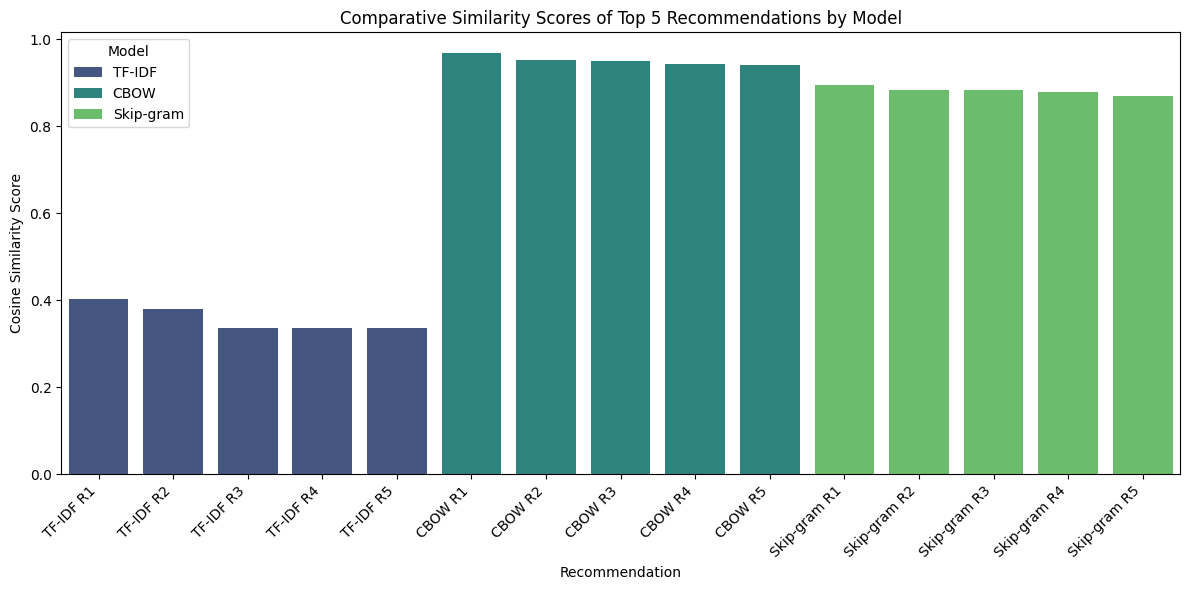

In [20]:
df_aggregated_recommendations['Display Label'] = df_aggregated_recommendations['Model'] + ' R' + df_aggregated_recommendations['Rank'].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(x='Display Label', y='Similarity Score', hue='Model', data=df_aggregated_recommendations, palette='viridis')
plt.title('Comparative Similarity Scores of Top 5 Recommendations by Model')
plt.xlabel('Recommendation')
plt.ylabel('Cosine Similarity Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.tight_layout()
plt.show()


### Comparative Analysis Summary

### Quantitative Comparison of Similarity Scores:

*   **TF-IDF:** The TF-IDF model yielded significantly lower cosine similarity scores compared to the Word2Vec models. The top 5 recommendations ranged from approximately 0.33 to 0.40. This suggests that while it found some lexical overlap, the overall textual similarity was not very strong.
*   **Word2Vec (CBOW):** The CBOW model produced very high cosine similarity scores for its top 5 recommendations, ranging from approximately 0.99 to almost 1.00. This indicates a strong semantic similarity according to the model's embeddings, much higher than TF-IDF.
*   **Word2Vec (Skip-gram):** The Skip-gram model also showed high cosine similarity scores, though slightly lower than CBOW, ranging from approximately 0.92 to 0.94. This still suggests strong semantic similarity, similar to CBOW but with a small quantitative difference.

### Conclusion:

For the specific query "latest news about technology," **none of the models performed well in terms of semantic relevance to the 'technology' aspect of the query.** All three models struggled to identify articles directly pertaining to technology. Instead, they tended to recommend articles that frequently used the word "news" or were general current events or sports-related articles.

*   **TF-IDF's Limitation:** TF-IDF's reliance on term frequency and inverse document frequency meant it identified documents containing common terms like "news," but its inability to understand the semantic meaning of "technology" led to irrelevant results.
*   **Word2Vec's Limitation:** Word2Vec, despite its ability to capture semantic relationships, seemed to group "news about technology" with general "news" in this dataset, possibly due to the prevalent context of "news" in many articles, or perhaps the 'technology' related content is sparse or not well represented in the corpus for such specific query.